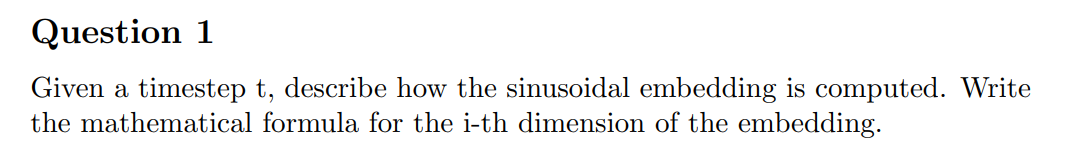

Given a timestep \(t\), the sinusoidal embedding is computed as:

$$
\mathrm{Emb}(t, 2i)
=
\sin\left(
\frac{t}{10000^{2i/d}}
\right)
$$

$$
\mathrm{Emb}(t, 2i+1)
=
\cos\left(
\frac{t}{10000^{2i/d}}
\right),
\qquad
i = 0,1,\ldots,\frac{d}{2}-1
$$

- t: the timestep
- d: the embedding dimension
- i: the index of the embedding dimension

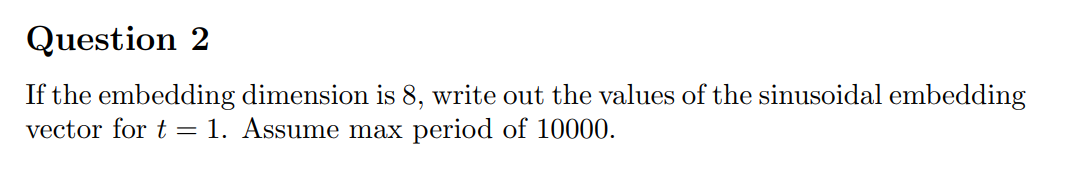

The given information is embedding dimension is 8, t = 1, so we can calculate the embedding for each dimension:

$$
10000^{2i/8}=1,\ 10,\ 100,\ 1000,
\qquad i=0,1,2,3.
$$

$$
\mathrm{Emb}(1)=
\left[
\sin(1),\cos(1),
\sin(0.1),\cos(0.1),
\sin(0.01),\cos(0.01),
\sin(0.001),\cos(0.001)
\right].
$$

Numerically,

$$
\mathrm{Emb}(1)\approx
[0.8415, 0.5403, 0.0998, 0.9950, 0.0100, 0.9999, 0.0010, 1.0000]
$$

In [2]:
import math
import torch

def sinusoidal_embedding(t, embedding_dim=8, max_period=10000):
    if embedding_dim % 2 != 0:
        raise ValueError("embedding_dim must be even")
    i = torch.arange(
        embedding_dim // 2, dtype=torch.float32
    )

    frequencies = torch.exp(-math.log(max_period) * 2 * i / embedding_dim)

    embedding = torch.zeros(embedding_dim)

    embedding[0::2] = torch.sin(t * frequencies)
    embedding[1::2] = torch.cos(t*frequencies)

    return embedding

embedding = sinusoidal_embedding(
    t=1.0,
    embedding_dim=8,
    max_period=10000
)

print(embedding)

tensor([0.8415, 0.5403, 0.0998, 0.9950, 0.0100, 0.9999, 0.0010, 1.0000])


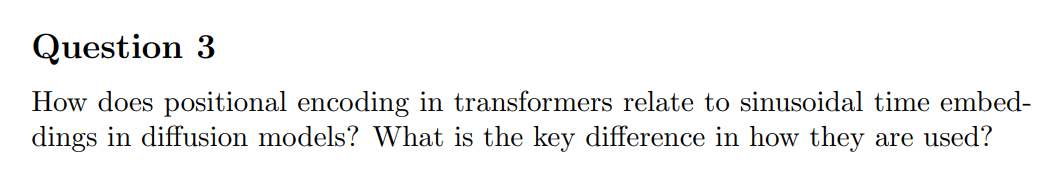
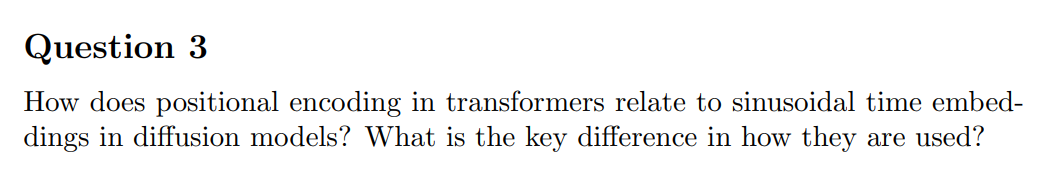

Both transformer positional encodings and diffusion timestep embeddings use sine and cosine functions with multiple frequencies to map a scalar position into a high-dimensional vector.

Their mathematical forms are very similar:

$$
PE(pos,2i)=
\sin\left(
\frac{pos}{10000^{2i/d}}
\right),
\qquad
PE(pos,2i+1)=
\cos\left(
\frac{pos}{10000^{2i/d}}
\right)
$$

For diffusion models, the timestep embedding can be written as

$$
TE(t,2i)=
\sin\left(
\frac{t}{10000^{2i/d}}
\right),
\qquad
TE(t,2i+1)=
\cos\left(
\frac{t}{10000^{2i/d}}
\right).
$$

The key difference is what the scalar represents and how the embedding is used. In transformers, the encoding represents the position of each token in a sequence and is usually added directly to the token embedding:

$$
h_{pos}=x_{pos}+PE(pos).
$$

In diffusion models, the embedding represents the current diffusion timestep, or noise level. It is usually passed through an MLP and injected into multiple layers of the denoising network:

$$
e_t=\mathrm{MLP}(TE(t)).
$$

Therefore, different tokens in a transformer receive different positional encodings, while all spatial locations of one diffusion sample usually share the same timestep embedding.

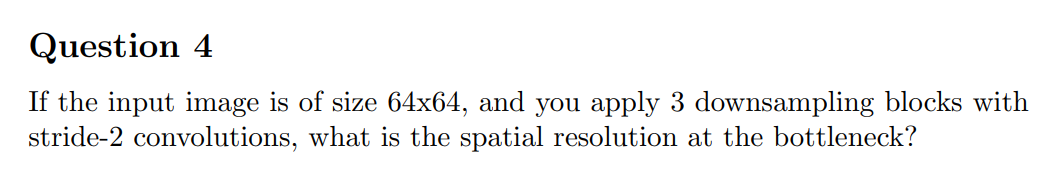

Input image is of size 64x64, stride is 2, and there are 3 downsampling layers. The output size can be calculated as follows:

64 -> 32 (after first downsampling)

32 -> 16 (after second downsampling)

16 -> 8 (after third downsampling)

So the spatial resolution at the bottleneck is 8x8.

Each stride-2 convolution reduces the spatial resolution by a factor of 2:

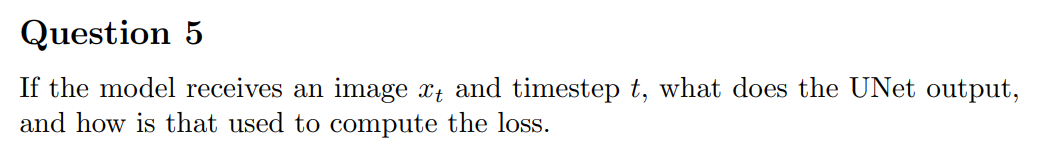

In a standard diffusion model, the UNet receives the noisy image \(x_t\) and the timestep \(t\), and predicts the noise that was added to the original image:

$$
\hat{\epsilon}
=
\epsilon_\theta(x_t,t).
$$

The noisy image is constructed as

$$
x_t
=
\sqrt{\bar{\alpha}_t}x_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0,I).
$$

The predicted noise is compared with the actual noise used to generate \(x_t\). The training loss is usually the mean squared error:

$$
\mathcal{L}
=
\mathbb{E}_{x_0,t,\epsilon}
\left[
\left\|
\epsilon-\epsilon_\theta(x_t,t)
\right\|_2^2
\right].
$$

Therefore, the UNet learns to identify and remove the noise present at each diffusion timestep.

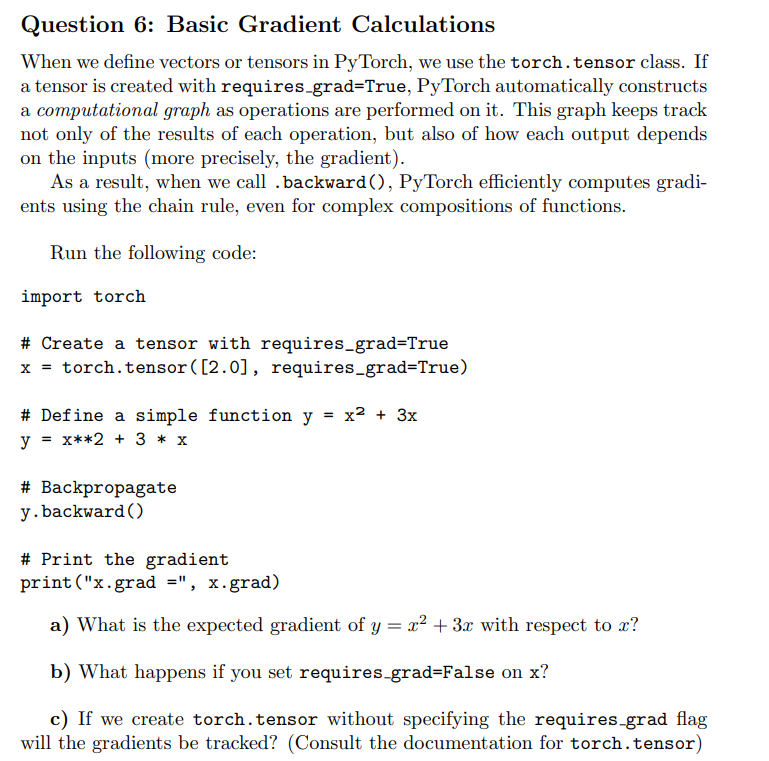

In [1]:
# a)
import torch

x = torch.tensor([2.0], requires_grad=True)

y = x ** 2 + 3 * x

y.backward()

print("x.grad = ", x.grad)

x.grad =  tensor([7.])


a) The expected gradient of y with respect to x is $2x+3$, at $x = 2$, the gradient is 7

In [2]:
# b)
x = torch.tensor([2.0], requires_grad=False)

y = x ** 2 + 3 * x

print("x.requires_grad =", x.requires_grad)
print("y.requires_grad =", y.requires_grad)
print("y.grad_fn =", y.grad_fn)
print("x.grad before backward =", x.grad)

try:
    y.backward()
except RuntimeError as error:
    print("Error:", error)

x.requires_grad = False
y.requires_grad = False
y.grad_fn = None
x.grad before backward = None
Error: element 0 of tensors does not require grad and does not have a grad_fn


b) Since requires_grad is set to False, the gradient will not be computed and x.grad will be None. And it will report an error when calling y.backward() because x does not require gradients. Pytorch does not construct a computational graph for x.

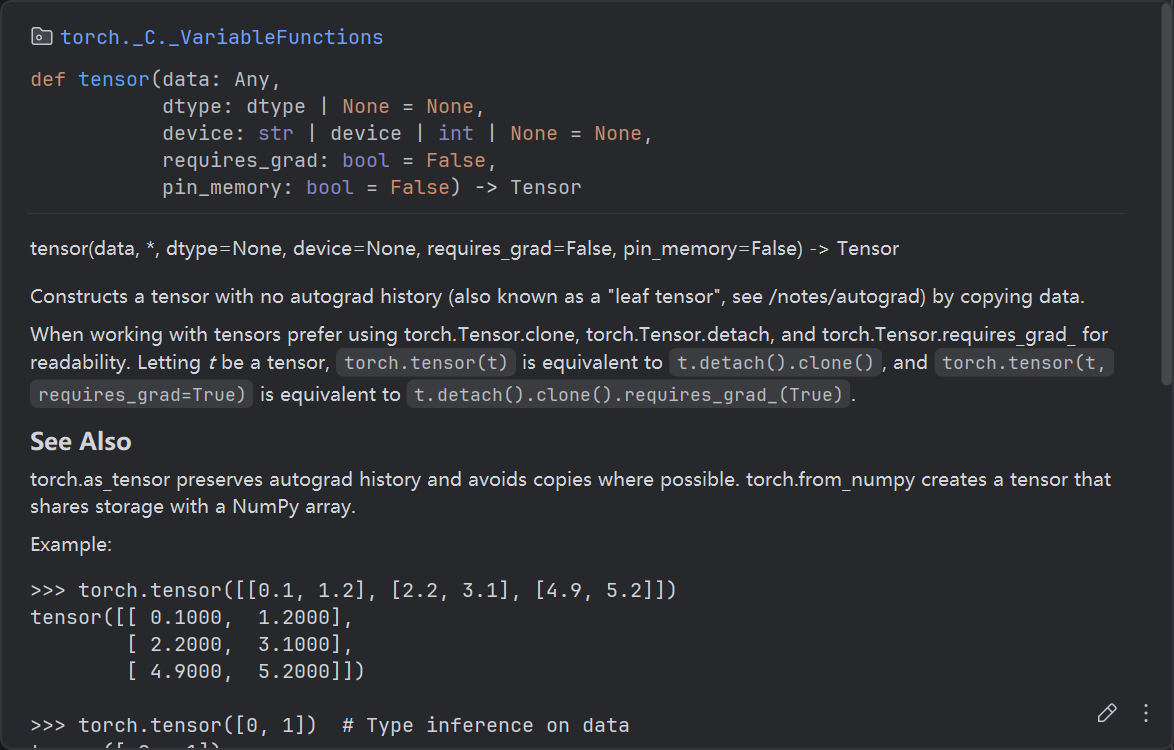

In [3]:
# c)
x = torch.tensor([2.0])

y = x ** 2 + 3 * x

print("x.requires_grad =", x.requires_grad)
print("y.requires_grad =", y.requires_grad)
print("x.grad =", x.grad)

try:
    y.backward()
except RuntimeError as error:
    print("Error:", error)

x.requires_grad = False
y.requires_grad = False
x.grad = None
Error: element 0 of tensors does not require grad and does not have a grad_fn


c) No it will not, the default value of requires_grad for torch.tensor is False, so gradients are not tracked unless it's set to True. It will report an error.

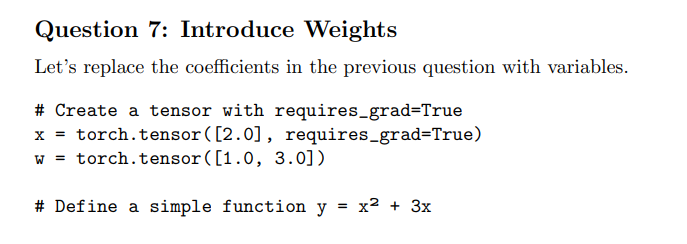

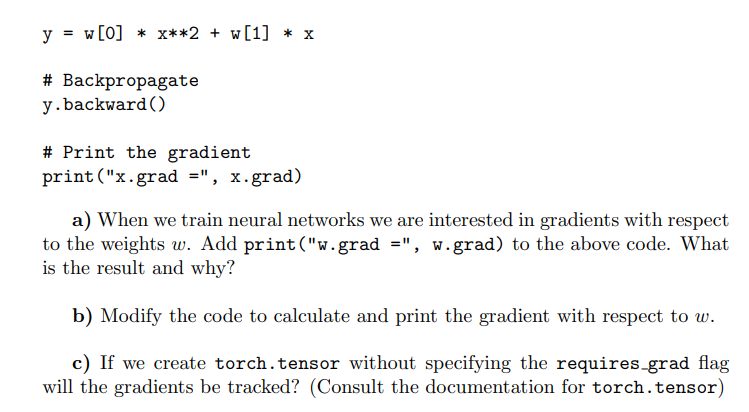

In [4]:
# a)
x = torch.tensor([2.0], requires_grad=True)
w = torch.tensor([1.0, 3.0])

y = w[0] * x **2 + w[1] * x

y.backward()

print("x.grad = ", x.grad)
print("w.grad =", w.grad)

x.grad =  tensor([7.])
w.grad = None


a) The result is that x.grad is 7.0, and w.grad is None. This is because w was created without setting requires_grad=True. By default, requires_grad is False, so PyTorch does not compute or store gradients with respect to w.

In [5]:
# a)
x = torch.tensor([2.0], requires_grad=True)
w = torch.tensor([1.0, 3.0], requires_grad=True)

y = w[0] * x **2 + w[1] * x

y.backward()

print("x.grad = ", x.grad)
print("w.grad =", w.grad)

x.grad =  tensor([7.])
w.grad = tensor([4., 2.])


b) The result is that x.grad is 7.0, and w.grad is tensor([4., 2.]).

In [6]:
# c)
x = torch.tensor([2.0])
w = torch.tensor([1.0, 3.0])

y = w[0] * x **2 + w[1] * x

print("x.requires_grad =", x.requires_grad)
print("y.requires_grad =", y.requires_grad)
print("w.requires_grad =", w.requires_grad)
print("w.grad =", w.grad)
print("x.grad =", x.grad)

try:
    y.backward()
except RuntimeError as error:
    print("Error:", error)

x.requires_grad = False
y.requires_grad = False
w.requires_grad = False
w.grad = None
x.grad = None
Error: element 0 of tensors does not require grad and does not have a grad_fn


c) No. If requires_grad is not specified, its default value is
False. Therefore, gradients with respect to that tensor will not be
tracked or stored. In this example, w.grad remains None unless
w is created with requires_grad=True.

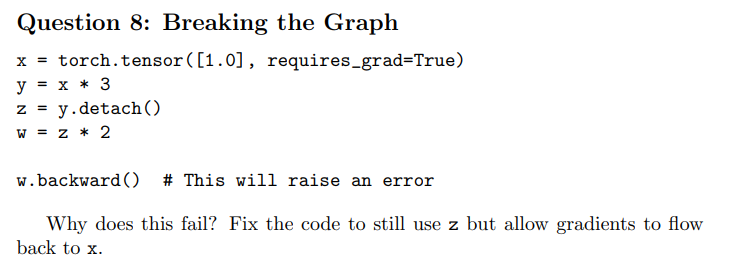

The code fails because y.detach() creates a new tensor that shares the same value as y but is disconnected from the computational graph. Therefore, z and w do not require gradients, and calling w.backward()
raises an error.

So to fix the code, removing the .detach() from y can be a solution. The gradient will be 6

In [7]:
x = torch.tensor([1.0], requires_grad=True)
y = x * 3
z = y
w = z * 2

w.backward()

print("x.grad =", x.grad)

x.grad = tensor([6.])


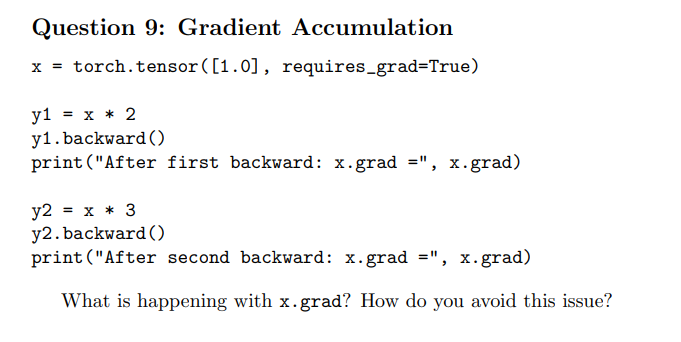

In [8]:
x = torch.tensor([1.0], requires_grad=True)

y1 = x * 2
y1.backward()
print("After first backward: x.grad = ", x.grad)

y2 = x * 3
y2.backward()
print("After second backward: x.grad = ", x.grad)

After first backward: x.grad =  tensor([2.])
After second backward: x.grad =  tensor([5.])


So the x.grad accumulates the gradients from both y1 and y2. When PyTorch using .backward(), it will not clear the existing gradients in .grad, instead, it will accumulate the new gradients to the existing ones. Therefore, after the first backward call, x.grad is 2. After the second backward call, x.grad becomes 5 (2 + 3).

To avoid this situation, using .grad.zero_() or set x.grad = None are both great ways to avoid the problem.

In [9]:
x = torch.tensor([1.0], requires_grad=True)

y1 = x * 2
y1.backward()
print("After first backward: x.grad =", x.grad)

x.grad.zero_()

y2 = x * 3
y2.backward()
print("After second backward: x.grad =", x.grad)

After first backward: x.grad = tensor([2.])
After second backward: x.grad = tensor([3.])


In [10]:
x = torch.tensor([1.0], requires_grad=True)

y1 = x * 2
y1.backward()
print("After first backward: x.grad =", x.grad)

x.grad = None

y2 = x * 3
y2.backward()
print("After second backward: x.grad =", x.grad)

After first backward: x.grad = tensor([2.])
After second backward: x.grad = tensor([3.])
